In [1]:
import matplotlib.pyplot as plt
import torch

from torch.utils.data import DataLoader
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Functions

class one_hidden_layer_fcn(nn.Module):
    def __init__(self, h):

        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(276, h), nn.ReLU(), nn.Linear(h, 1),
        )

    def forward(self, x):

        logits = self.linear_relu_stack(x)
        return logits.squeeze()


def train_loop(dataloader, model, loss_fn, optimizer, device):

    for X, y in dataloader:

        X = X.to(device)
        y = y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


def eval_loop(dataloader, model, loss_fn, device):

    num_batches = len(dataloader)
    loss = 0

    with torch.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            loss += loss_fn(pred, y).item()

    loss /= num_batches

    return loss


Text(0.5, 0, 'Energy (kcal/mol)')

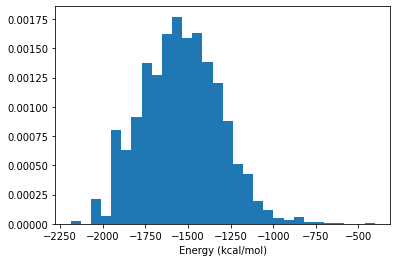

In [3]:
dataset = torch.load("./dataset.pt")

X_train, y_train = dataset["X_train"], dataset["y_train"]
X_val, y_val = dataset["X_val"], dataset["y_val"]
X_test, y_test = dataset["X_test"], dataset["y_test"]

plt.hist(y_train, bins=30, density=True)
plt.xlabel("Energy (kcal/mol)")


In [4]:
y_train_mean, y_train_std = y_train.mean(), y_train.std()

y_train = (y_train - y_train_mean) / y_train_std
y_val = (y_val - y_train_mean) / y_train_std
y_test = (y_test - y_train_mean) / y_train_std


In [5]:
train_data = torch.utils.data.TensorDataset(X_train, y_train)
val_data = torch.utils.data.TensorDataset(X_val, y_val)
test_data = torch.utils.data.TensorDataset(X_test, y_test)

batch_size = 100

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

torch.manual_seed(0)

h = 1000
model = one_hidden_layer_fcn(h).to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

epochs = 1000

ts = []
tr_lss = []
val_lss = []
for t in range(epochs):

    train_loop(train_dataloader, model, loss_fn, optimizer, device)

    if (t % 4) == 0:
        train_error = (
            eval_loop(train_dataloader, model, loss_fn,
                      device) * y_train_std ** 2
        ).item()
        ts.append(t)
        tr_lss.append(train_error)
        val_error = (eval_loop(val_dataloader, model, loss_fn,
                     device) * y_train_std ** 2).item()
        val_lss.append(val_error)


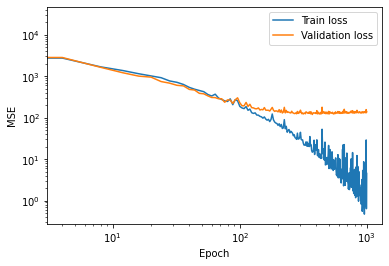

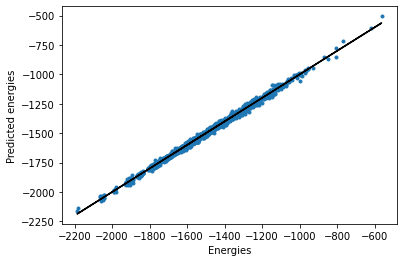

Test MSE: 169.22 (kcal/mol)^2
Test RMSE: 13.01 kcal/mol


In [6]:
plt.loglog(ts, tr_lss, label="Train loss")
plt.loglog(ts, val_lss, label="Validation loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

plt.plot(y_test * y_train_std + y_train_mean, 
         model(X_test.to(device)).detach().cpu() * y_train_std + y_train_mean, '.')
plt.plot(y_test * y_train_std + y_train_mean,
         y_test * y_train_std + y_train_mean, 'k')
plt.xlabel('Energies')
plt.ylabel('Predicted energies')
plt.show()

test_error = (eval_loop(
    test_dataloader, model, loss_fn, device)* y_train_std ** 2).item()
print(f"Test MSE: {test_error:.2f} (kcal/mol)^2")
print(f"Test RMSE: {(test_error ** 0.5):.2f} kcal/mol")


In [7]:
ns = [100, 200, 500, 1000]
errs = []

for n in ns:

    train_data = torch.utils.data.TensorDataset(X_train[:n], y_train[:n])

    batch_size = 100

    train_dataloader = DataLoader(
        train_data, batch_size=batch_size, shuffle=True)

    torch.manual_seed(0)

    h = 1000
    model = one_hidden_layer_fcn(h).to(device)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), 1e-4)

    epochs = 1000

    for t in range(epochs):

        train_loop(train_dataloader, model, loss_fn, optimizer, device)

    errs.append(
        (eval_loop(test_dataloader, model, loss_fn, device) * y_train_std ** 2).item())


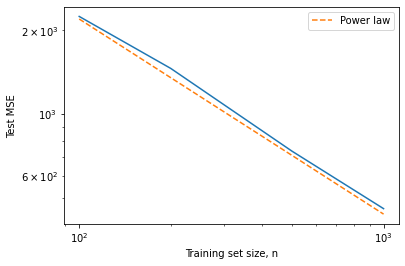

Predicted test error with n=4000 points: 165.55 (kcal/mol)^2
Actual test error: 169.22 (kcal/mol)^2


In [8]:
plt.loglog(ns, errs)
A = 5.5e4
b = 0.7
plt.loglog(ns, torch.tensor(ns)**(-b)*A, linestyle='dashed', label="Power law")
plt.xlabel('Training set size, n')
plt.ylabel('Test MSE')
plt.legend()
plt.show()

print(f"Predicted test error with n=4000 points: {(4000**(-b)*A):.2f} (kcal/mol)^2")
print(f"Actual test error: {test_error:.2f} (kcal/mol)^2")
